# 1. IMPORT LIBRARIES

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_log_error
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

warnings.filterwarnings("ignore")
plt.style.use('seaborn')
plt.rcParams['figure.figsize'] = (12,6)

# 2. LOAD DATA

In [18]:
train = pd.read_csv(r"D:\Data\New folder9999999999\train.csv")
test = pd.read_csv(r"D:\Data\New folder9999999999\test.csv")
stores = pd.read_csv(r"D:\Data\New folder9999999999\stores.csv")
oil = pd.read_csv(r"D:\Data\New folder9999999999\oil.csv")
holidays = pd.read_csv(r"D:\Data\New folder9999999999\holidays_events.csv")
transactions = pd.read_csv(r"D:\Data\New folder9999999999\transactions.csv")

for df in [train, test, oil, holidays, transactions]:
    df['date'] = pd.to_datetime(df['date'])

# 3. DATA CLEANING & MERGING

In [20]:
train = train.sort_values('date').reset_index(drop=True)
test  = test.sort_values('date').reset_index(drop=True)

oil = oil.sort_values('date')
oil['dcoilwtico'] = oil['dcoilwtico'].ffill().bfill()

holidays_clean = holidays[
    (holidays['transferred'] == False) &
    (holidays['type'] != 'Transfer')
].copy()

holidays_clean['is_holiday'] = 1
holidays_clean = holidays_clean[['date', 'is_holiday']].drop_duplicates()

def merge_external_data(df):
    df = df.merge(stores, on='store_nbr', how='left')
    df = df.merge(oil, on='date', how='left')
    df['dcoilwtico'] = df['dcoilwtico'].ffill()
    
    df = df.merge(holidays_clean, on='date', how='left')
    df['is_holiday'] = df['is_holiday'].fillna(0).astype(int)
    
    df = df.merge(transactions, on=['date', 'store_nbr'], how='left')
    df['transactions'] = df['transactions'].fillna(0)
    
    return df

train = merge_external_data(train)
test  = merge_external_data(test)

print(train.shape, test.shape)

(3000888, 13) (28512, 12)


# 4. FEATURE ENGINEERING

In [21]:
for df in [train, test]:
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    df['dayofweek'] = df['date'].dt.dayofweek
    df['is_weekend'] = df['dayofweek'].isin([5,6]).astype(int)
    df['is_promotion'] = (df['onpromotion'] > 0).astype(int)

train = train.sort_values(['store_nbr','family','date'])

for lag in [1,7,14]:
    train[f'sales_lag_{lag}'] = train.groupby(['store_nbr','family'])['sales'].shift(lag)

for window in [7,30]:
    train[f'sales_roll_mean_{window}'] = train.groupby(['store_nbr','family'])['sales'].transform(lambda x: x.shift(1).rolling(window).mean())

for lag in [1,7]:
    train[f'oil_lag_{lag}'] = train['dcoilwtico'].shift(lag)

train['oil_roll7'] = train['dcoilwtico'].shift(1).rolling(7).mean()
train['transactions_roll7'] = train.groupby('store_nbr')['transactions'].transform(lambda x: x.shift(1).rolling(7).mean())

train.fillna(0, inplace=True)
test.fillna(0, inplace=True)


# 5. LABEL ENCODING CATEGORICALS

In [22]:
cat_cols = ['family','city','state','type','cluster']
for col in cat_cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col])
    test[col] = le.transform(test[col])

# 6. PREPARE TRAINING & VALIDATION SETS

In [23]:
test_id = test['id'].copy()
drop_cols = ['id','date','onpromotion']

train_model = train.drop(columns=drop_cols)
test_model = test.drop(columns=['id','date','onpromotion'])

TARGET = 'sales'
features = [col for col in train_model.columns if col != TARGET]

X = train_model[features]
y = np.log1p(train_model[TARGET]) 

split_date = X['year'].quantile(0.95)
X_train = X[X['year'] < split_date]
X_val = X[X['year'] >= split_date]
y_train = y.loc[X_train.index]
y_val = y.loc[X_val.index]

print("Training set:", X_train.shape, "Validation set:", X_val.shape)

Training set: (2596374, 24) Validation set: (404514, 24)


# 7. MODEL TRAINING

In [24]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
lgb_model.fit(X_train, y_train, eval_set=[(X_val,y_val)], eval_metric='rmse', callbacks=[lgb.log_evaluation(period=50)])

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.306653 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3011
[LightGBM] [Info] Number of data points in the train set: 2596374, number of used features: 24
[LightGBM] [Info] Start training from score 2.825141
[50]	valid_0's rmse: 0.510302	valid_0's l2: 0.260408
[100]	valid_0's rmse: 0.448184	valid_0's l2: 0.200869
[150]	valid_0's rmse: 0.441367	valid_0's l2: 0.194804
[200]	valid_0's rmse: 0.439058	valid_0's l2: 0.192772
[250]	valid_0's rmse: 0.436713	valid_0's l2: 0.190719
[300]	valid_0's rmse: 0.431901	valid_0's l2: 0.186539


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, n_estimators=300,
              random_state=42, subsample=0.8)

In [25]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method='hist'
)
xgb_model.fit(X_train, y_train, eval_set=[(X_val,y_val)], verbose=50)

[0]	validation_0-rmse:2.53001
[50]	validation_0-rmse:0.48514
[100]	validation_0-rmse:0.43620
[150]	validation_0-rmse:0.43074
[200]	validation_0-rmse:0.42968
[250]	validation_0-rmse:0.42865
[299]	validation_0-rmse:0.42802


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=8, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=300, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [26]:
cat_model = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    depth=8,
    verbose=50,
    random_state=42
)
cat_model.fit(X_train, y_train, eval_set=(X_val,y_val))

0:	learn: 2.5754172	test: 2.5329790	best: 2.5329790 (0)	total: 1.35s	remaining: 6m 42s
50:	learn: 0.5029199	test: 0.5235457	best: 0.5235457 (50)	total: 1m	remaining: 4m 54s
100:	learn: 0.4249261	test: 0.4555517	best: 0.4555517 (100)	total: 1m 56s	remaining: 3m 50s
150:	learn: 0.4113724	test: 0.4463299	best: 0.4463299 (150)	total: 2m 53s	remaining: 2m 50s
200:	learn: 0.4021542	test: 0.4418224	best: 0.4418224 (200)	total: 3m 47s	remaining: 1m 52s
250:	learn: 0.3966697	test: 0.4392344	best: 0.4392171 (247)	total: 4m 43s	remaining: 55.3s
299:	learn: 0.3925603	test: 0.4374788	best: 0.4374788 (299)	total: 5m 37s	remaining: 0us

bestTest = 0.4374788431
bestIteration = 299



# 8. VALIDATION RMSLE COMPARISON

In [27]:
models = {
    'LightGBM': lgb_model,
    'XGBoost': xgb_model,
    'CatBoost': cat_model
}

rmsle_scores = {}
y_true = np.expm1(y_val)
y_true = np.clip(y_true,0,None)

for name, model_i in models.items():
    val_preds = model_i.predict(X_val)
    val_preds = np.expm1(val_preds)
    val_preds = np.clip(val_preds,0,None)
    rmsle = np.sqrt(mean_squared_log_error(y_true, val_preds))
    rmsle_scores[name] = rmsle
    print(f"{name} RMSLE: {rmsle:.5f}")

LightGBM RMSLE: 0.43187
XGBoost RMSLE: 0.42800
CatBoost RMSLE: 0.43748


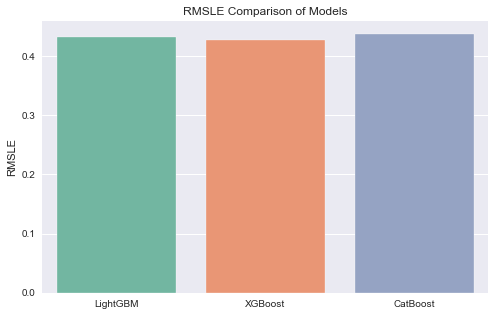

In [28]:
plt.figure(figsize=(8,5))
sns.barplot(x=list(rmsle_scores.keys()), y=list(rmsle_scores.values()), palette='Set2')
plt.title("RMSLE Comparison of Models")
plt.ylabel("RMSLE")
plt.show()

# 9. FEATURE IMPORTANCE PLOTS

<Figure size 864x432 with 0 Axes>

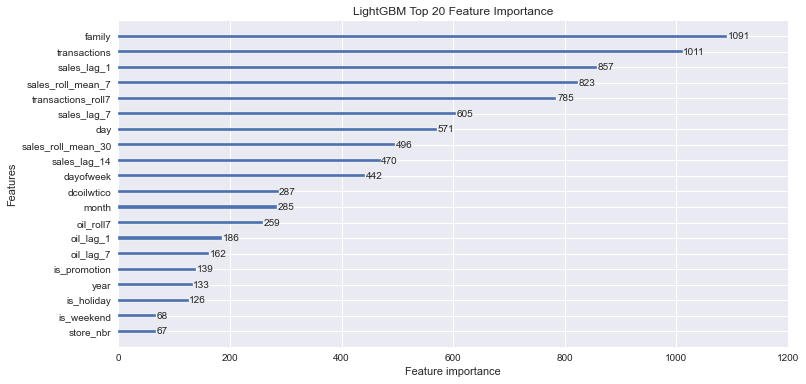

In [29]:
plt.figure(figsize=(12,6))
lgb.plot_importance(lgb_model, max_num_features=20)
plt.title("LightGBM Top 20 Feature Importance")
plt.show()

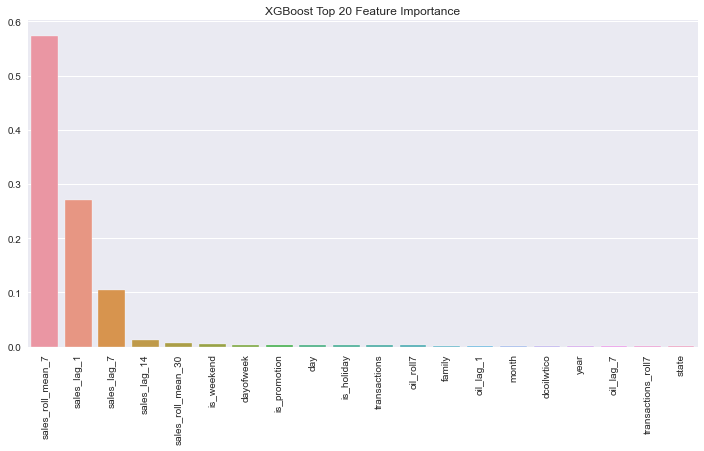

In [30]:
plt.figure(figsize=(12,6))
feat_importance_xgb = pd.Series(xgb_model.feature_importances_, index=features).sort_values(ascending=False)
sns.barplot(x=feat_importance_xgb[:20].index, y=feat_importance_xgb[:20].values)
plt.xticks(rotation=90)
plt.title("XGBoost Top 20 Feature Importance")
plt.show()

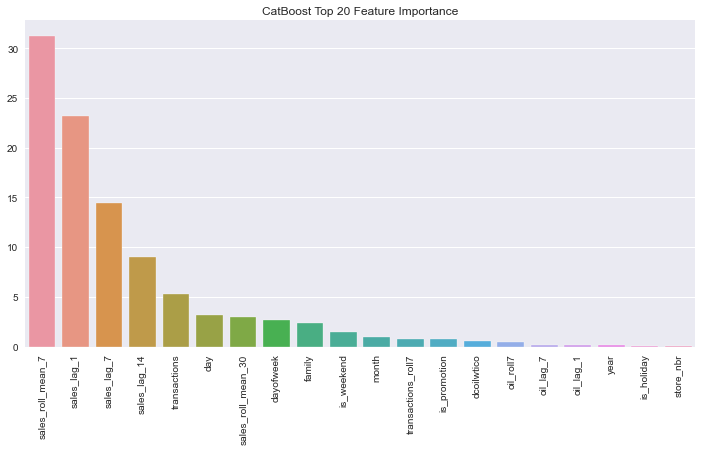

In [31]:
plt.figure(figsize=(12,6))
feat_importance_cat = pd.Series(cat_model.get_feature_importance(), index=features).sort_values(ascending=False)
sns.barplot(x=feat_importance_cat[:20].index, y=feat_importance_cat[:20].values)
plt.xticks(rotation=90)
plt.title("CatBoost Top 20 Feature Importance")
plt.show()

# 10. ENSEMBLE PREDICTION (XGB + LGB + CAT)

In [34]:
for col in features:
    if col not in test_model.columns:
        test_model[col] = 0

test_model = test_model[features]

xgb_preds = np.expm1(xgb_model.predict(test_model))
lgb_preds = np.expm1(lgb_model.predict(test_model))
cat_preds = np.expm1(cat_model.predict(test_model))

test_preds = (
    0.5 * xgb_preds +
    0.4 * lgb_preds +
    0.1 * cat_preds
)

test_preds = np.clip(test_preds, 0, None)

print("Ensemble prediction completed successfully!")

Ensemble prediction completed successfully!


# 11. SUBMISSION

In [35]:
submission = pd.DataFrame({
    'id': test_id,
    'sales': test_preds
})
submission.to_csv('submission_final.csv', index=False)
print("Submission created successfully!.")

Submission created successfully!.


In [36]:
submission.describe()

,id,sales
count,2.851200e+04,28512.000000
mean,3.015144e+06,20.326275
std,8.230850e+03,23.801816
min,3.000888e+06,0.000000
25%,3.008016e+06,0.008233
50%,3.015144e+06,0.022437
75%,3.022271e+06,42.760634
max,3.029399e+06,86.189067


In [37]:
(submission['sales'] < 0).sum() 

0

In [38]:
submission.isnull().sum()

id       0
sales    0
dtype: int64